In [22]:
import pandas as pd
import numpy as np
import os
import sys

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))

In [16]:
data_train = pd.read_csv("../../../dataset/Spotify_train_preprocesado_clasificacion.csv")

data_test = pd.read_csv("../../../dataset/Spotify_test_preprocesado_clasificacion.csv")

df_train = data_train.copy()
df_test = data_test.copy()

print("Dataset de entrenamiento: ")
display(df_train.head())


print("Dataset de pruebas: ")
display(df_test.head())

Dataset de entrenamiento: 


,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,...,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity_category
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.360656,0.407609,0.005418,...,-0.557598,0.751125,-0.804229,0.532848,-0.562123,-0.436477,1.542740,-0.147610,-0.695300,1
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.360656,0.100464,-0.034422,...,-0.017461,0.751125,-0.785413,0.623235,-0.606882,-0.678120,1.183864,0.437714,-0.191994,0
2,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.927115,-1.881489,0.216573,...,0.430609,0.751125,-0.519639,-0.618079,-0.580263,-0.985860,-1.305115,0.437984,0.625209,2
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.360656,1.746296,0.336094,...,0.571210,-1.331337,-0.500823,-0.710274,-0.606882,-0.635477,-0.506326,0.064335,-0.879964,0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.360656,0.726344,-1.795371,...,-2.390784,-1.331337,1.124396,1.430692,1.793755,-0.671013,1.195440,2.664353,-0.772929,2


Dataset de pruebas: 


,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,...,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity_category
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.927115,-1.452645,-1.914892,...,-2.318107,0.751125,-0.700742,1.813330,1.793755,-0.700153,-1.619613,-0.133029,1.330330,0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.360656,1.798453,0.626930,...,1.478109,0.751125,0.865678,-0.675324,-0.606764,1.390062,1.450127,-0.406397,-0.528812,0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.360656,0.639416,0.224541,...,0.842404,0.751125,-0.199770,-0.940037,-0.606785,-0.724317,1.303489,2.353574,-0.550148,0
3,1.0,0.0,0.0,0.0,1.0,1.0,0.0,-1.648427,-0.067596,0.754419,...,0.438615,0.751125,2.126046,1.707878,-0.606882,2.409939,0.292462,-1.350621,-1.566635,1
4,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.927115,0.830657,1.093063,...,1.257701,0.751125,-0.380872,-0.942719,1.793755,-1.048403,1.006355,0.096426,1.158399,0


In [17]:
# Separación de variables predictoras y objetivo
X_train = df_train.drop(
    columns=["popularity_category"]
)

y_train = df_train[
    "popularity_category"
]

X_test = df_test.drop(
    columns=["popularity_category"]
)

y_test = df_test[
    "popularity_category"
]

# Testeo de KNN con K = 3 y 5

In [23]:
results = []

for k in [3, 5]:

    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights="uniform",
        metric="euclidean",
        n_jobs=-1
    )

    scores = cross_validate(
        knn,
        X_train,
        y_train,
        cv=5,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision_weighted",
            "recall": "recall_weighted",
            "f1": "f1_weighted"
        },
        n_jobs=-1
    )

    results.append({
        "K": k,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1-Score": scores["test_f1"].mean()
    })

results_knn = pd.DataFrame(results)

print(results_knn)

   K  Accuracy  Precision    Recall  F1-Score
0  3  0.695928   0.687737  0.695928  0.685035
1  5  0.682133   0.672121  0.682133  0.671360


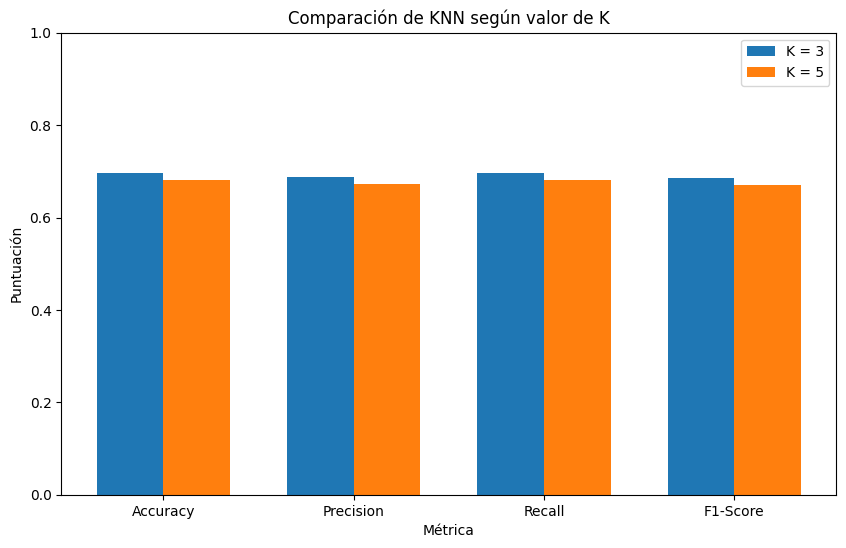

In [24]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    [i - width / 2 for i in x],
    results_knn.loc[0, metrics],
    width=width,
    label="K = 3"
)

plt.bar(
    [i + width / 2 for i in x],
    results_knn.loc[1, metrics],
    width=width,
    label="K = 5"
)

plt.xticks(x, metrics)
plt.ylabel("Puntuación")
plt.xlabel("Métrica")
plt.title("Comparación de KNN según valor de K")
plt.ylim(0, 1)
plt.legend()

plt.show()

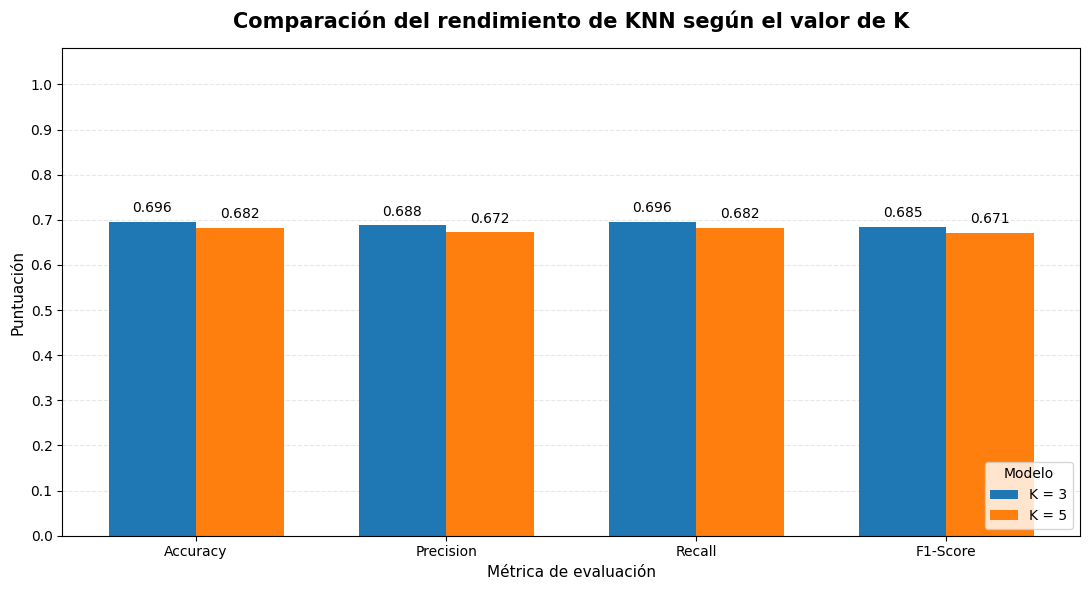

In [25]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

x = np.arange(len(metrics))
width = 0.35

k3_values = results_knn.loc[0, metrics].values
k5_values = results_knn.loc[1, metrics].values

fig, ax = plt.subplots(figsize=(11, 6))

bars_k3 = ax.bar(
    x - width / 2,
    k3_values,
    width,
    label="K = 3"
)

bars_k5 = ax.bar(
    x + width / 2,
    k5_values,
    width,
    label="K = 5"
)

# Valores sobre las barras
for bars in [bars_k3, bars_k5]:
    for bar in bars:
        value = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.015,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

# Configuración
ax.set_title(
    "Comparación del rendimiento de KNN según el valor de K",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Métrica de evaluación",
    fontsize=11
)

ax.set_ylabel(
    "Puntuación",
    fontsize=11
)

ax.set_xticks(x)
ax.set_xticklabels(metrics)

ax.set_ylim(0, 1.08)

ax.set_yticks(np.arange(0, 1.1, 0.1))

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

ax.legend(
    title="Modelo",
    loc="lower right"
)

plt.tight_layout()
plt.show()